# Renewable Energy Generation Prediction Model

This notebook implements a Feedforward Neural Network (FFN) using TensorFlow to predict solar and wind energy generation in Spain based on historical energy data.

In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Load and Prepare Data

Load the cleaned dataset and merge it with weather data for the prediction model.

In [3]:
# Load the cleaned energy data
clean_csv_path = os.path.join(os.path.dirname(os.getcwd()), 'clean_energy_data.csv')
print(f"Loading cleaned data from: {clean_csv_path}")
df = pd.read_csv(clean_csv_path, parse_dates=['utc_timestamp'])
df.set_index('utc_timestamp', inplace=True)

# Select Spain's energy features
es_columns = [col for col in df.columns if 'BE_' in col]
# Prepare features and targets for renewable generation
target_cols = ['BE_solar_generation_actual', 'BE_wind_onshore_generation_actual']
feature_cols = [col for col in es_columns if col not in target_cols]

# Create feature dataframe
df_features = df[feature_cols + target_cols].copy()

# Drop any rows with missing values
df_features = df_features.dropna()

# Reset the index to work with the timestamp column
df_with_time_features = df_features.reset_index()

# Extract time-based features
df_with_time_features['hour'] = df_with_time_features['utc_timestamp'].dt.hour
df_with_time_features['day'] = df_with_time_features['utc_timestamp'].dt.day
df_with_time_features['month'] = df_with_time_features['utc_timestamp'].dt.month
df_with_time_features['day_of_week'] = df_with_time_features['utc_timestamp'].dt.dayofweek
df_with_time_features['is_weekend'] = df_with_time_features['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Create cyclical features for hour, day, and month to capture periodicity
df_with_time_features['hour_sin'] = np.sin(2 * np.pi * df_with_time_features['hour']/24)
df_with_time_features['hour_cos'] = np.cos(2 * np.pi * df_with_time_features['hour']/24)
df_with_time_features['month_sin'] = np.sin(2 * np.pi * df_with_time_features['month']/12)
df_with_time_features['month_cos'] = np.cos(2 * np.pi * df_with_time_features['month']/12)



# Show the time features added
print("\nTime-based features added:")
time_cols = ['hour', 'day', 'month', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']
print(time_cols)
print("\nSample of data with time features:")
display(df_with_time_features[time_cols + target_cols].head())

Loading cleaned data from: C:\Users\danee\PycharmProjects\Project-2-2\my_shit\clean_energy_data.csv

Time-based features added:
['hour', 'day', 'month', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']

Sample of data with time features:


,hour,day,month,day_of_week,is_weekend,hour_sin,hour_cos,month_sin,month_cos,BE_solar_generation_actual,BE_wind_onshore_generation_actual
0,0,1,1,3,0,0.000000,1.000000,0.5,0.866025,92.66,216.15
1,1,1,1,3,0,0.258819,0.965926,0.5,0.866025,92.66,216.15
2,2,1,1,3,0,0.500000,0.866025,0.5,0.866025,92.66,237.18
3,3,1,1,3,0,0.707107,0.707107,0.5,0.866025,92.66,326.19
4,4,1,1,3,0,0.866025,0.500000,0.5,0.866025,92.66,317.50


## Attempt to Integrate Weather Data

Let's try to load the Spanish weather data and merge it with our energy data to capture weather-related seasonality.

In [4]:
# Load the Spain weather data
weather_path = os.path.join(os.path.dirname(os.getcwd()), 'weather_data', 'BE_hourly_2015-2019.csv')
print(f"Loading weather data from: {weather_path}")

try:
    # ✅ FIXED: Use 'timestamp' instead of 'time'
    weather_df = pd.read_csv(weather_path, parse_dates=['timestamp'])
    

    # ✅ Rename for merging
    weather_df = weather_df.rename(columns={'timestamp': 'utc_timestamp'})

    weather_df['utc_timestamp'] = pd.to_datetime(weather_df['utc_timestamp']).dt.tz_localize('UTC')


    print("\nWeather data columns:")
    print(weather_df.columns.tolist())
    print("\nWeather data sample:")
    display(weather_df.head())

    # ✅ Merge with energy data
    merged_data = pd.merge(df_with_time_features, weather_df, on='utc_timestamp', how='left')

    print("\nShape before merging with weather:", df_with_time_features.shape)
    print("Shape after merging with weather:", merged_data.shape)
    print("\nSample of merged data:")
    display(merged_data.head())

    # ✅ Handle missing values in weather columns
    weather_cols = [col for col in merged_data.columns if col not in df_with_time_features.columns]
    missing_weather = merged_data[weather_cols].isnull().sum()
    print("\nMissing values in weather columns:")
    print(missing_weather)

    if missing_weather.max() > 0:
        print("\nWARNING: Missing weather values detected. Imputing with forward-fill + back-fill.")
        merged_data[weather_cols] = merged_data[weather_cols].ffill().bfill()
    else:
        print("\nSuccessfully merged weather data without missing values!")

    # ✅ Final merged dataset with weather + time + energy
    df_merged = merged_data

except Exception as e:
    print(f"\nError loading weather data: {e}")
    raise e

print("\nFinal merged columns:")
print(df_merged.columns.tolist())


Loading weather data from: C:\Users\danee\PycharmProjects\Project-2-2\my_shit\weather_data\BE_hourly_2015-2019.csv

Weather data columns:
['utc_timestamp', 'temp', 'humidity', 'cloudcover', 'wind_speed', 'wind_direction', 'pressure', 'shortwave_radiation', 'zone']

Weather data sample:


,utc_timestamp,temp,humidity,cloudcover,wind_speed,wind_direction,pressure,shortwave_radiation,zone
0,2015-01-01 00:00:00+00:00,-0.3,96,17,10.6,215,1036.4,0.0,BE
1,2015-01-01 01:00:00+00:00,-0.7,96,48,11.8,211,1036.4,0.0,BE
2,2015-01-01 02:00:00+00:00,-0.8,95,60,12.7,209,1036.3,0.0,BE
3,2015-01-01 03:00:00+00:00,-0.9,95,79,14.2,201,1035.8,0.0,BE
4,2015-01-01 04:00:00+00:00,-0.8,95,82,15.2,202,1035.4,0.0,BE



Shape before merging with weather: (43824, 14)
Shape after merging with weather: (43824, 22)

Sample of merged data:


,utc_timestamp,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,BE_wind_onshore_generation_actual,hour,day,month,day_of_week,is_weekend,...,month_sin,month_cos,temp,humidity,cloudcover,wind_speed,wind_direction,pressure,shortwave_radiation,zone
0,2015-01-01 00:00:00+00:00,9484.0,9897.0,92.66,216.15,0,1,1,3,0,...,0.5,0.866025,-0.3,96,17,10.6,215,1036.4,0.0,BE
1,2015-01-01 01:00:00+00:00,9152.0,9521.0,92.66,216.15,1,1,1,3,0,...,0.5,0.866025,-0.7,96,48,11.8,211,1036.4,0.0,BE
2,2015-01-01 02:00:00+00:00,8799.0,9135.0,92.66,237.18,2,1,1,3,0,...,0.5,0.866025,-0.8,95,60,12.7,209,1036.3,0.0,BE
3,2015-01-01 03:00:00+00:00,8567.0,8909.0,92.66,326.19,3,1,1,3,0,...,0.5,0.866025,-0.9,95,79,14.2,201,1035.8,0.0,BE
4,2015-01-01 04:00:00+00:00,8487.0,8806.0,92.66,317.50,4,1,1,3,0,...,0.5,0.866025,-0.8,95,82,15.2,202,1035.4,0.0,BE



Missing values in weather columns:
temp                   0
humidity               0
cloudcover             0
wind_speed             0
wind_direction         0
pressure               0
shortwave_radiation    0
zone                   0
dtype: int64

Successfully merged weather data without missing values!

Final merged columns:
['utc_timestamp', 'BE_load_actual_entsoe_transparency', 'BE_load_forecast_entsoe_transparency', 'BE_solar_generation_actual', 'BE_wind_onshore_generation_actual', 'hour', 'day', 'month', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'temp', 'humidity', 'cloudcover', 'wind_speed', 'wind_direction', 'pressure', 'shortwave_radiation', 'zone']


In [5]:



print("\nAvailable Belgium (BE) columns:")
print(es_columns)


print("\nFinal dataset shape:", df_features.shape)
print("\nFeatures used:")
print(feature_cols)
print("\nTarget columns:")
print(target_cols)
print("\nFirst few rows:")
display(df_merged.head())
weather_columns = [col for col in df_merged.columns if col not in es_columns + ['utc_timestamp']]
print("\nDetected weather columns:")
print(weather_columns)



Available Belgium (BE) columns:
['BE_load_actual_entsoe_transparency', 'BE_load_forecast_entsoe_transparency', 'BE_solar_generation_actual', 'BE_wind_onshore_generation_actual']

Final dataset shape: (43824, 4)

Features used:
['BE_load_actual_entsoe_transparency', 'BE_load_forecast_entsoe_transparency']

Target columns:
['BE_solar_generation_actual', 'BE_wind_onshore_generation_actual']

First few rows:


,utc_timestamp,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,BE_wind_onshore_generation_actual,hour,day,month,day_of_week,is_weekend,...,month_sin,month_cos,temp,humidity,cloudcover,wind_speed,wind_direction,pressure,shortwave_radiation,zone
0,2015-01-01 00:00:00+00:00,9484.0,9897.0,92.66,216.15,0,1,1,3,0,...,0.5,0.866025,-0.3,96,17,10.6,215,1036.4,0.0,BE
1,2015-01-01 01:00:00+00:00,9152.0,9521.0,92.66,216.15,1,1,1,3,0,...,0.5,0.866025,-0.7,96,48,11.8,211,1036.4,0.0,BE
2,2015-01-01 02:00:00+00:00,8799.0,9135.0,92.66,237.18,2,1,1,3,0,...,0.5,0.866025,-0.8,95,60,12.7,209,1036.3,0.0,BE
3,2015-01-01 03:00:00+00:00,8567.0,8909.0,92.66,326.19,3,1,1,3,0,...,0.5,0.866025,-0.9,95,79,14.2,201,1035.8,0.0,BE
4,2015-01-01 04:00:00+00:00,8487.0,8806.0,92.66,317.50,4,1,1,3,0,...,0.5,0.866025,-0.8,95,82,15.2,202,1035.4,0.0,BE



Detected weather columns:
['hour', 'day', 'month', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'temp', 'humidity', 'cloudcover', 'wind_speed', 'wind_direction', 'pressure', 'shortwave_radiation', 'zone']


## Add Time-Based Features

Let's extract time-based features from the timestamp index to help the model capture seasonality and daily patterns.

## Prepare Features and Target

Split the data into features (X) and target (y), and then into training and testing sets.

In [14]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load your already-merged dataframe
df = df_merged.copy()
print("Columns in merged data:")
print(df.columns.tolist())

# --- Target Columns ---
solar_col = 'BE_solar_generation_actual'
wind_col = 'BE_wind_onshore_generation_actual'
target_cols = [solar_col, wind_col]

# --- Feature Columns ---

# Load-related features
entsoe_var = 'BE_load_actual_entsoe_transparency'

# Dynamically find meteorological columns (not in the original df_with_time_features)
core_cols = ['utc_timestamp', entsoe_var] + target_cols + [
    'hour', 'day', 'month', 'day_of_week',
    'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos'
]
weather_cols = [
    col for col in df.columns
    if col not in core_cols and pd.api.types.is_numeric_dtype(df[col])
]

# --- Add lag features ---
for col in target_cols:
    for lag in [1, 24]:
        df[f'{col}_lag_{lag}'] = df[col].shift(lag)

# --- Drop rows with NaNs ---
required_cols = [entsoe_var] + weather_cols + target_cols + [
    f'{solar_col}_lag_1', f'{solar_col}_lag_24',
    f'{wind_col}_lag_1', f'{wind_col}_lag_24'
]
df = df.dropna(subset=required_cols)
df = df.drop(columns=['zone'], errors='ignore')

# --- Input features ---
input_cols = (
    [entsoe_var] +
    weather_cols +
    ['hour', 'month', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos'] +
    [f'{solar_col}_lag_1', f'{solar_col}_lag_24',
     f'{wind_col}_lag_1', f'{wind_col}_lag_24']
)

# --- Normalize ---
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X = X_scaler.fit_transform(df[input_cols])
y = y_scaler.fit_transform(df[target_cols])

# --- Train/test split ---
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# --- Optional: print shapes and confirm
print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("\nFeatures used:", input_cols)


Columns in merged data:
['utc_timestamp', 'BE_load_actual_entsoe_transparency', 'BE_load_forecast_entsoe_transparency', 'BE_solar_generation_actual', 'BE_wind_onshore_generation_actual', 'hour', 'day', 'month', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'temp', 'humidity', 'cloudcover', 'wind_speed', 'wind_direction', 'pressure', 'shortwave_radiation', 'zone']

X_train shape: (35040, 21)
y_train shape: (35040, 2)

Features used: ['BE_load_actual_entsoe_transparency', 'BE_load_forecast_entsoe_transparency', 'temp', 'humidity', 'cloudcover', 'wind_speed', 'wind_direction', 'pressure', 'shortwave_radiation', 'hour', 'month', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'BE_solar_generation_actual_lag_1', 'BE_solar_generation_actual_lag_24', 'BE_wind_onshore_generation_actual_lag_1', 'BE_wind_onshore_generation_actual_lag_24']


## Build the Feedforward Neural Network Model

Create a simple FFN model using TensorFlow's Keras API.

In [33]:
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Dropout
import matplotlib.pyplot as plt

# --- Model with Shared Base and Task-Specific Heads ---
input_layer = Input(shape=(X_train.shape[1],), name='input')

shared = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(input_layer)
shared = Dropout(0.3)(shared)
shared = Dense(64, activation='relu')(shared)

# Task-specific solar head
solar_head = Dense(32, activation='relu')(shared)
solar_output = Dense(1, name='solar_output')(solar_head)

# Task-specific wind head
wind_head = Dense(32, activation='relu')(shared)
wind_output = Dense(1, name='wind_output')(wind_head)

model = Model(
    inputs=input_layer,
    outputs={
        'solar_output': solar_output,
        'wind_output': wind_output
    }
)

model.compile(
    optimizer='adam',
    loss='mse',
    metrics={
        'solar_output': 'mae',
        'wind_output': 'mae'
    }
)

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 13)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 128)       │      1,792 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_24[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 32)        │      2,080 │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 32)        │      2,080 │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ solar_output        │ (None, 1)         │         33 │ dense_26[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wind_output (Dense) │ (None, 1)         │         33 │ dense_27[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,274 (55.76 KB)

 Trainable params: 14,274 (55.76 KB)

 Non-trainable params: 0 (0.00 B)

## Train the Model

Train the model on the training data and monitor its performance.


Including weather features:
['temp', 'humidity', 'cloudcover', 'wind_speed', 'wind_direction', 'pressure', 'shortwave_radiation', 'zone']
Training set shape: (35059, 13)
Testing set shape: (8765, 13)
Features used: 14
y_train_solar shape: (35059,)
y_train_wind shape: (35059,)
Epoch 1/50
877/877 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.4059 - solar_output_loss: 0.1544 - solar_output_mae: 0.2616 - wind_output_loss: 0.2295 - wind_output_mae: 0.3431 - val_loss: 0.2854 - val_solar_output_loss: 0.0935 - val_solar_output_mae: 0.1824 - val_wind_output_loss: 0.1731 - val_wind_output_mae: 0.2929
Epoch 2/50
877/877 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2061 - solar_output_loss: 0.0736 - solar_output_mae: 0.1661 - wind_output_loss: 0.1158 - wind_output_mae: 0.2484 - val_loss: 0.3196 - val_solar_output_loss: 0.1247 - val_solar_output_mae: 0.1979 - val_wind_output_loss: 0.1797 - val_wind_output_mae: 0.2960
Epoch 3/50
877/877 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1887 - solar_output_loss

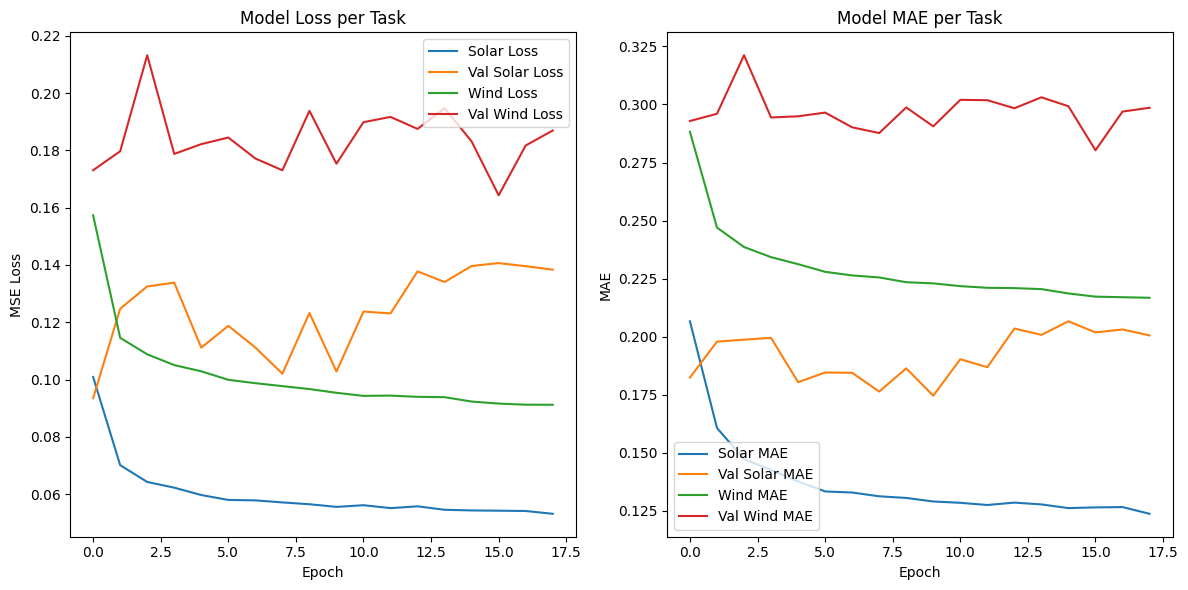

In [34]:




# Define target columns
target_cols = ['BE_solar_generation_actual', 'BE_wind_onshore_generation_actual']

# Define feature columns - now including time-based features
# Filter out load-related features in addition to the target columns
irrelevant_cols = target_cols + [col for col in es_columns if 'load' in col.lower()]
original_feature_cols = [col for col in es_columns if col not in irrelevant_cols]


# Add time features to the feature list
time_feature_cols = ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_of_week', 'is_weekend']

# Check if weather columns are available
weather_cols = [col for col in df_merged.columns if col not in df_with_time_features.columns and col != 'utc_timestamp']
if weather_cols:
    print("\nIncluding weather features:")
    print(weather_cols)
    all_feature_cols = original_feature_cols + time_feature_cols + weather_cols
else:
    print("\nNo weather features available, using time features only.")
    all_feature_cols = original_feature_cols + time_feature_cols

# Ensure datetime index
df_merged = df_merged.copy()

df_merged['utc_timestamp'] = pd.to_datetime(df_merged['utc_timestamp'])
df_merged['hour'] = df_merged['utc_timestamp'].dt.hour
df_merged['month'] = df_merged['utc_timestamp'].dt.month
df_merged['day_of_week'] = df_merged['utc_timestamp'].dt.dayofweek
df_merged['is_weekend'] = df_merged['day_of_week'].isin([5, 6]).astype(int)

# Sine/cosine transformation for cyclical features
df_merged['hour_sin'] = np.sin(2 * np.pi * df_merged['hour'] / 24)
df_merged['hour_cos'] = np.cos(2 * np.pi * df_merged['hour'] / 24)
df_merged['month_sin'] = np.sin(2 * np.pi * df_merged['month'] / 12)
df_merged['month_cos'] = np.cos(2 * np.pi * df_merged['month'] / 12)

# Separate features and targets
X = df_merged[all_feature_cols].select_dtypes(include=['number'])
y = df_merged[target_cols]

# Scale both features and targets
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

X_scaled = feature_scaler.fit_transform(X)
y_scaled = target_scaler.fit_transform(y)

# Split the data into training and testing sets
# before splitting, save the raw datetime index
timestamps = df_merged.index.to_numpy()

# now split everything together
X_train, X_test, \
y_train, y_test, \
time_train, time_test = train_test_split(
    X_scaled, y_scaled, timestamps,
    test_size=0.2, random_state=42, shuffle=False
)

# Split y into individual targets
y_train_solar = y_train[:, 0]
y_train_wind = y_train[:, 1]
y_test_solar = y_test[:, 0]
y_test_wind = y_test[:, 1]


print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Features used:", len(all_feature_cols))
print("y_train_solar shape:", y_train_solar.shape)
print("y_train_wind shape:", y_train_wind.shape)

assert isinstance(y_train_solar, np.ndarray)
assert isinstance(y_train_wind, np.ndarray)
assert len(y_train_solar.shape) == 1
assert len(y_train_wind.shape) == 1

# Train the model
history = model.fit(
    X_train,
    {'solar_output': y_train_solar, 'wind_output': y_train_wind},
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=[early_stopping]
)
# Plot training history
plt.figure(figsize=(12, 6))

# Plot losses
plt.subplot(1, 2, 1)
plt.plot(history.history['solar_output_loss'], label='Solar Loss')
plt.plot(history.history['val_solar_output_loss'], label='Val Solar Loss')
plt.plot(history.history['wind_output_loss'], label='Wind Loss')
plt.plot(history.history['val_wind_output_loss'], label='Val Wind Loss')
plt.title('Model Loss per Task')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()

# Plot MAEs
plt.subplot(1, 2, 2)
plt.plot(history.history['solar_output_mae'], label='Solar MAE')
plt.plot(history.history['val_solar_output_mae'], label='Val Solar MAE')
plt.plot(history.history['wind_output_mae'], label='Wind MAE')
plt.plot(history.history['val_wind_output_mae'], label='Val Wind MAE')
plt.title('Model MAE per Task')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()



## Evaluate Model Performance

Evaluate the model's performance on the test set and visualize predictions.

274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 690us/step

📊 Metrics for Solar Generation:
  Mean Squared Error:      33,815.62
  Root Mean Squared Error: 183.89
  Mean Absolute Error:     98.74

📊 Metrics for Wind Generation:
  Mean Squared Error:      26,869.79
  Root Mean Squared Error: 163.92
  Mean Absolute Error:     111.68


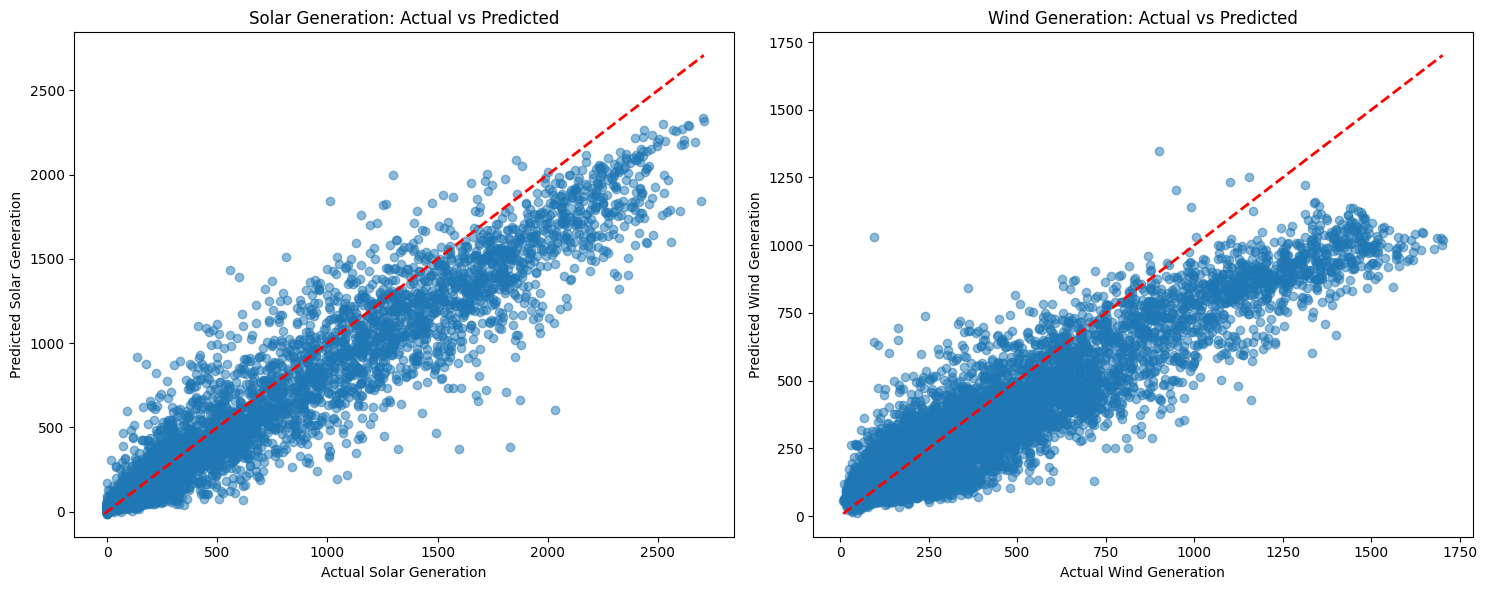

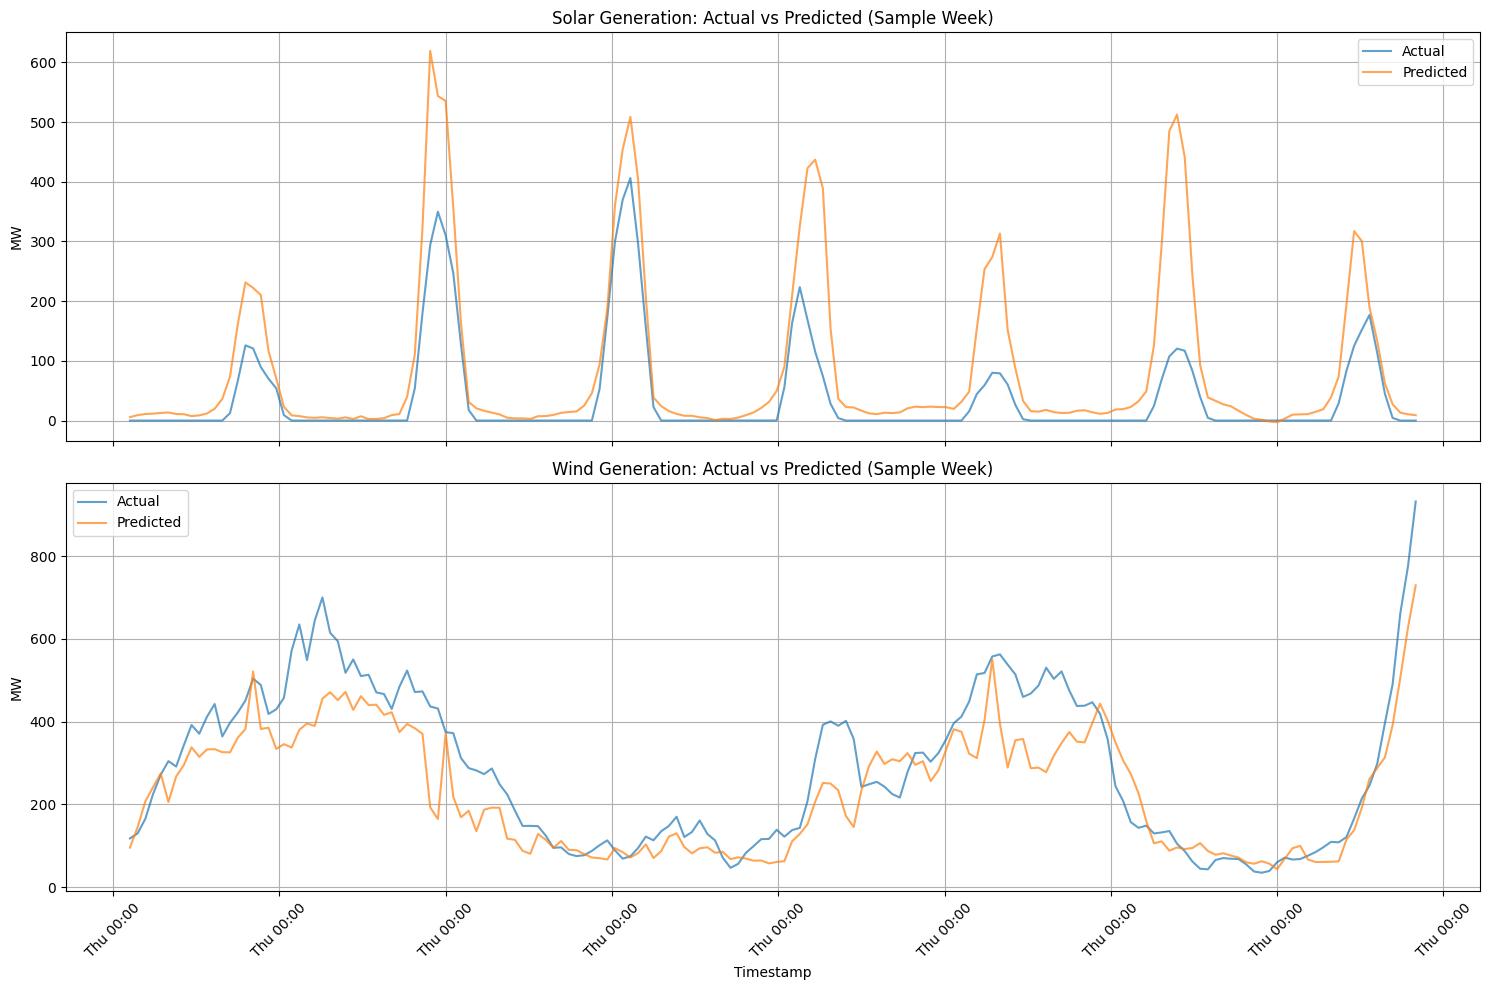

In [40]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
import pandas as pd
import numpy as np
import tensorflow as tf

# === Step 4: Predict ===
y_pred = model.predict(X_test)  # [solar_preds, wind_preds]
y_pred_combined = np.hstack([
    y_pred['solar_output'],
    y_pred['wind_output']
])

# === Step 5: Inverse scale and wrap with timestamps ===
y_test_inv = target_scaler.inverse_transform(y_test)
y_pred_inv = target_scaler.inverse_transform(y_pred_combined)

# Wrap in DataFrames
y_test_df = pd.DataFrame(y_test_inv, columns=target_cols, index=pd.to_datetime(time_test))
y_pred_df = pd.DataFrame(y_pred_inv, columns=target_cols, index=pd.to_datetime(time_test))

# === Step 6: Print evaluation metrics ===
for col, label in zip(target_cols, ['Solar Generation', 'Wind Generation']):
    mse = np.mean((y_test_df[col] - y_pred_df[col]) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_test_df[col] - y_pred_df[col]))
    
    print(f"\n📊 Metrics for {label}:")
    print(f"  Mean Squared Error:      {mse:,.2f}")
    print(f"  Root Mean Squared Error: {rmse:,.2f}")
    print(f"  Mean Absolute Error:     {mae:,.2f}")

# === Step 7: Scatter plot: Actual vs Predicted ===
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for i, (col, title) in enumerate(zip(target_cols, ['Solar Generation', 'Wind Generation'])):
    ax = axes[i]
    ax.scatter(y_test_df[col], y_pred_df[col], alpha=0.5)
    min_val = min(y_test_df[col].min(), y_pred_df[col].min())
    max_val = max(y_test_df[col].max(), y_pred_df[col].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    ax.set_xlabel(f'Actual {title}')
    ax.set_ylabel(f'Predicted {title}')
    ax.set_title(f'{title}: Actual vs Predicted')
plt.tight_layout()
plt.show()

# === Step 8: Time Series Plot (1 Week Sample) ===
sample_size = 168
sample_index = y_test_df.index[:sample_size]
y_test_sample = y_test_df.loc[sample_index]
y_pred_sample = y_pred_df.loc[sample_index]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Solar
ax1.plot(sample_index, y_test_sample[target_cols[0]], label='Actual', alpha=0.7)
ax1.plot(sample_index, y_pred_sample[target_cols[0]], label='Predicted', alpha=0.7)
ax1.set_title('Solar Generation: Actual vs Predicted (Sample Week)')
ax1.set_ylabel('MW')
ax1.legend()
ax1.grid(True)

# Wind
ax2.plot(sample_index, y_test_sample[target_cols[1]], label='Actual', alpha=0.7)
ax2.plot(sample_index, y_pred_sample[target_cols[1]], label='Predicted', alpha=0.7)
ax2.set_title('Wind Generation: Actual vs Predicted (Sample Week)')
ax2.set_xlabel('Timestamp')
ax2.set_ylabel('MW')
ax2.legend()
ax2.grid(True)

# Format X axis (midnight and midday ticks)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%a %H:%M'))
ax2.xaxis.set_major_locator(MaxNLocator(nbins=10))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()


Locator attempting to generate 1252 ticks ([35061.0, ..., 43818.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1252 ticks ([35061.0, ..., 43818.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1252 ticks ([35061.0, ..., 43818.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1252 ticks ([35061.0, ..., 43818.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1252 ticks ([35061.0, ..., 43818.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1252 ticks ([35061.0, ..., 43818.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1252 ticks ([35061.0, ..., 43818.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1252 ticks ([35061.0, ..., 43818.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1252 ticks ([35061.0, ..., 43818.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to genera

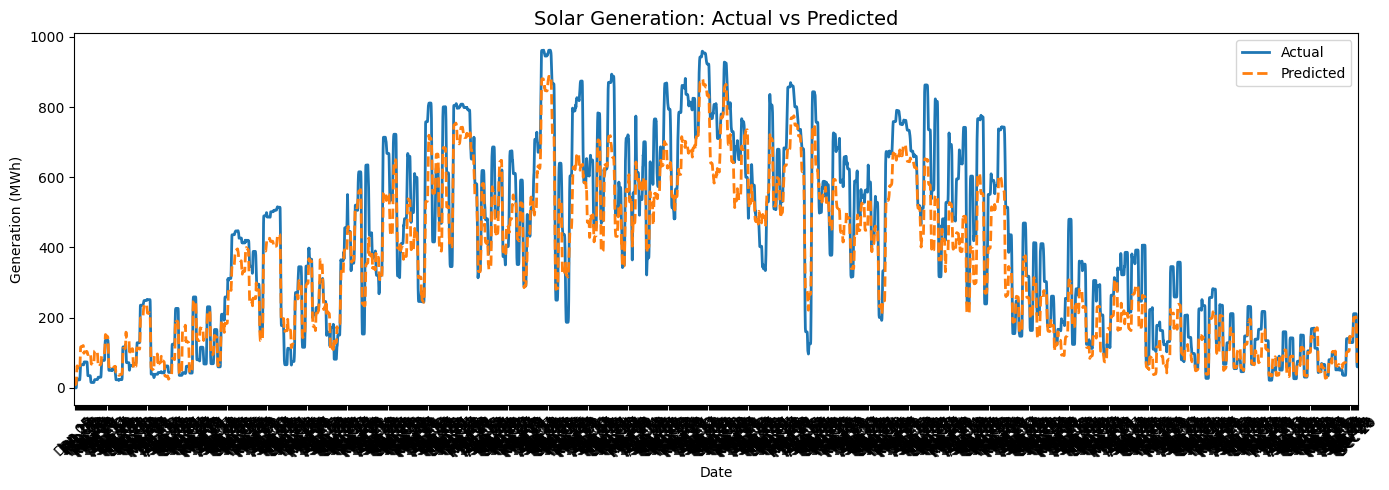

Locator attempting to generate 1252 ticks ([35061.0, ..., 43818.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1252 ticks ([35061.0, ..., 43818.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1252 ticks ([35061.0, ..., 43818.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1252 ticks ([35061.0, ..., 43818.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1252 ticks ([35061.0, ..., 43818.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1252 ticks ([35061.0, ..., 43818.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1252 ticks ([35061.0, ..., 43818.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1252 ticks ([35061.0, ..., 43818.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1252 ticks ([35061.0, ..., 43818.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to genera

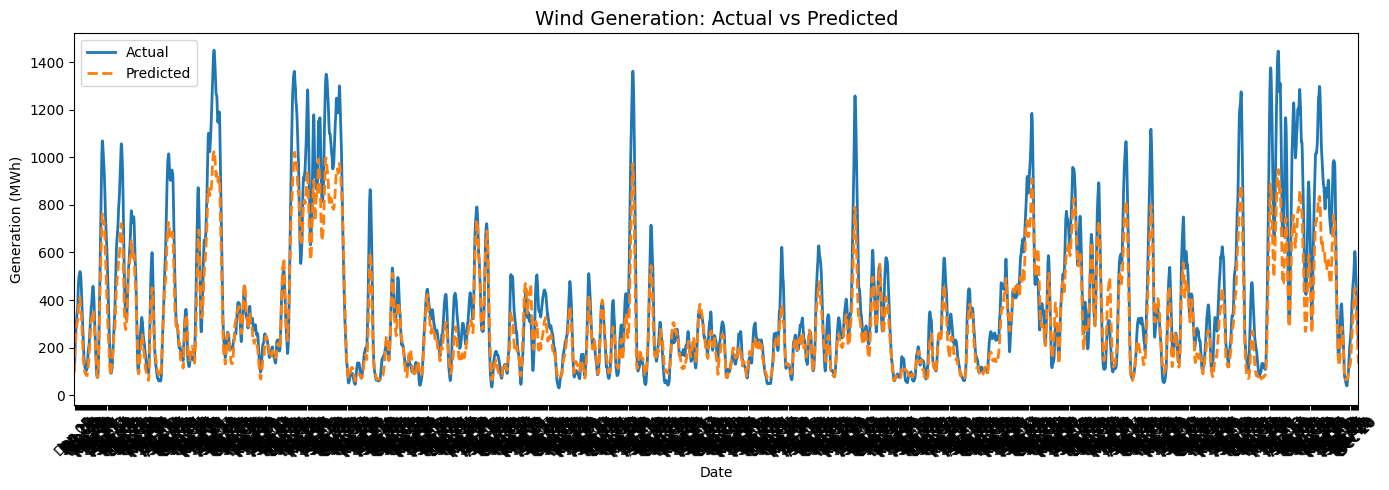

In [45]:

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

# Apply a 24-hour rolling average for smoothness (optional)
smooth_y_test = y_test_df.rolling(window=24, min_periods=1).mean()
smooth_y_pred = y_pred_df.rolling(window=24, min_periods=1).mean()


# === Solar Generation ===
plt.figure(figsize=(14, 5))
ax = smooth_y_test['BE_solar_generation_actual'].plot(label='Actual', linewidth=2)
smooth_y_pred['BE_solar_generation_actual'].plot(label='Predicted', ax=ax, linestyle='--', linewidth=2)

ax.set_title('Solar Generation: Actual vs Predicted', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Generation (MWh)')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

# === Wind Generation ===
plt.figure(figsize=(14, 5))
ax = smooth_y_test['BE_wind_onshore_generation_actual'].plot(label='Actual', linewidth=2)
smooth_y_pred['BE_wind_onshore_generation_actual'].plot(label='Predicted', ax=ax, linestyle='--', linewidth=2)

ax.set_title('Wind Generation: Actual vs Predicted', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Generation (MWh)')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()



In [10]:
# Compare first 10 solar generation values
sample_index = y_test_df.index[:10]

comparison = pd.DataFrame({
    "Timestamp": sample_index,
    "df_merged (true solar)": df_merged.loc[sample_index, 'ES_solar_generation_actual'].values,
    "y_test_df (inv)": y_test_df.loc[sample_index, 'ES_solar_generation_actual'].values,
    "y_pred_df": y_pred_df.loc[sample_index, 'ES_solar_generation_actual'].values
})

print(comparison.to_string(index=False))

                Timestamp  df_merged (true solar)  y_test_df (inv)   y_pred_df
2018-12-31 19:00:00+00:00                    33.0             33.0 1603.445312
2018-12-31 20:00:00+00:00                    31.0             31.0 1613.516968
2018-12-31 21:00:00+00:00                    31.0             31.0 1631.347778
2018-12-31 22:00:00+00:00                    31.0             31.0 1641.041138
2018-12-31 23:00:00+00:00                    31.0             31.0 1653.191895
2019-01-01 00:00:00+00:00                    31.0             31.0 1578.933838
2019-01-01 01:00:00+00:00                    23.0             23.0 1594.718628
2019-01-01 02:00:00+00:00                    15.0             15.0 1618.763306
2019-01-01 03:00:00+00:00                    15.0             15.0 1629.162231
2019-01-01 04:00:00+00:00                    15.0             15.0 1651.497681


## Sample Predictions

Visualize a sample of predictions over time to see how well the model tracks actual values.

## Feature Importance

Let's analyze which features are most important for predicting renewable energy generation.

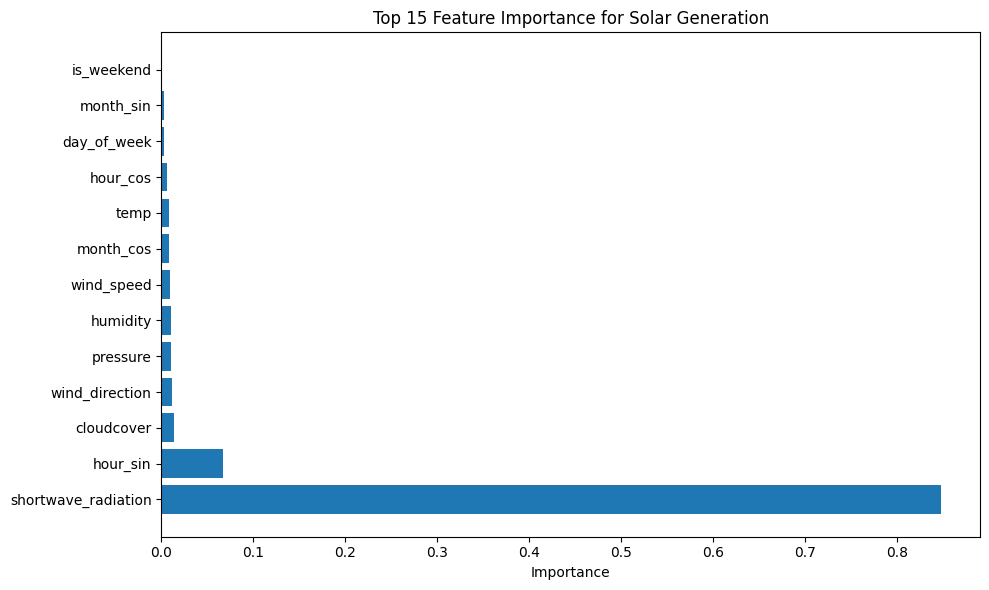


Top 10 features for Solar Generation:
1. shortwave_radiation: 0.8483
2. hour_sin: 0.0666
3. cloudcover: 0.0140
4. wind_direction: 0.0118
5. pressure: 0.0107
6. humidity: 0.0102
7. wind_speed: 0.0094
8. month_cos: 0.0083
9. temp: 0.0083
10. hour_cos: 0.0064


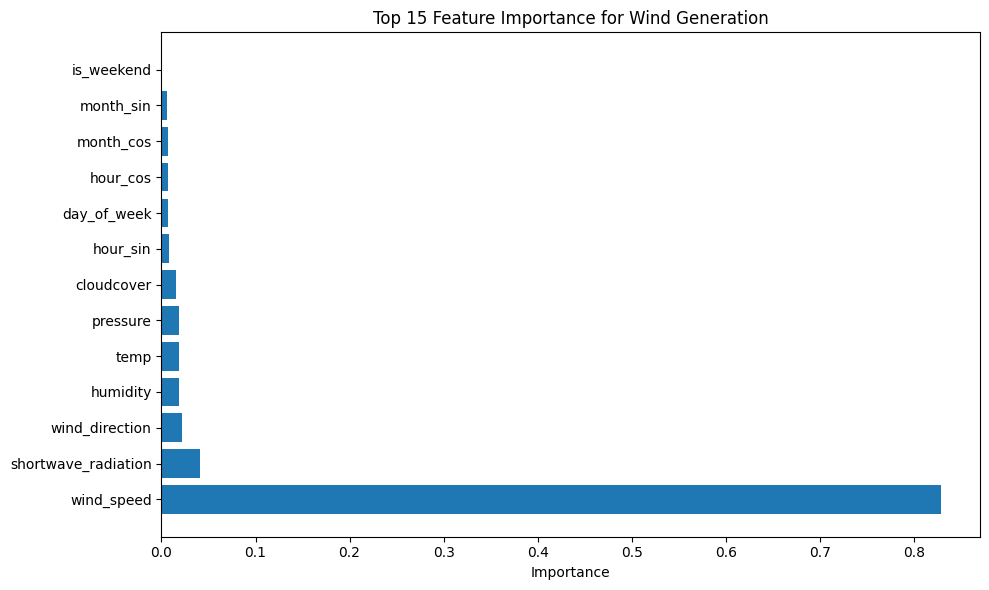


Top 10 features for Wind Generation:
1. wind_speed: 0.8290
2. shortwave_radiation: 0.0414
3. wind_direction: 0.0218
4. humidity: 0.0188
5. temp: 0.0188
6. pressure: 0.0184
7. cloudcover: 0.0152
8. hour_sin: 0.0079
9. day_of_week: 0.0072
10. hour_cos: 0.0072


In [46]:
# We can estimate feature importance by using a simple approach
# Train a RandomForest model which provides feature importance
from sklearn.ensemble import RandomForestRegressor

try:
    # Train separate models for solar and wind
    importances = []
    feature_names = all_feature_cols
    
    for i, target_name in enumerate(['Solar Generation', 'Wind Generation']):
        # Train a Random Forest model
        rf_model = RandomForestRegressor(n_estimators=50, random_state=42)
        rf_model.fit(X_train, y_train[:, i])
        
        # Get feature importance
        importance = rf_model.feature_importances_
        importances.append(importance)
        
        # Sort features by importance
        sorted_idx = importance.argsort()[::-1]
        
        # Plot feature importance
        plt.figure(figsize=(10, 6))
        plt.barh(range(len(sorted_idx[:15])), importance[sorted_idx[:15]])
        plt.yticks(range(len(sorted_idx[:15])), [feature_names[i] for i in sorted_idx[:15]])
        plt.title(f'Top 15 Feature Importance for {target_name}')
        plt.xlabel('Importance')
        plt.tight_layout()
        plt.show()
        
        # Print top 10 features
        print(f"\nTop 10 features for {target_name}:")
        for i, idx in enumerate(sorted_idx[:10]):
            print(f"{i+1}. {feature_names[idx]}: {importance[idx]:.4f}")
    
except Exception as e:
    print(f"Error in feature importance analysis: {e}")
    print("Skipping feature importance analysis.")

Model lacks recurrence or sequence awareness
You're using a feedforward network (Dense layers), which treats every hour independently — it has no memory of what came before or after.

In [47]:
def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

sequence_length = 24  # past 24 hours
X_seq, y_seq = create_sequences(X_scaled, y_scaled, sequence_length)

# Split into train/test
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, shuffle=False
)

print("X shape:", X_train_seq.shape)
print("y shape:", y_train_seq.shape)


X shape: (35040, 24, 13)
y shape: (35040, 2)


In [60]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

# Input shape: (sequence_length, num_features)
input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])
inputs = Input(shape=input_shape, name="input_sequence")

# Shared GRU + dense representation
x = GRU(128, return_sequences=False)(inputs)
x = Dropout(0.2)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)

# --- Solar Head ---
solar_dense = Dense(32, activation='relu')(x)
solar_output = Dense(1, name='solar_output')(solar_dense)

# --- Wind Head ---
wind_dense = Dense(32, activation='relu')(x)
wind_output = Dense(1, name='wind_output')(wind_dense)

# Combine into model
model = Model(inputs=inputs, outputs={'solar_output': solar_output, 'wind_output': wind_output})

# Compile with named losses/metrics
model.compile(
    optimizer='adam',
    loss={'solar_output': 'mse', 'wind_output': 'mse'},
    metrics={'solar_output': 'mae', 'wind_output': 'mae'}
)

model.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 24, 13)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_7 (GRU)         │ (None, 128)       │     54,912 │ input_sequence[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 128)       │          0 │ gru_7[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_43 (Dense)    │ (None, 64)        │      8,256 │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 64)        │          0 │ dense_43[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_44 (Dense)    │ (None, 32)        │      2,080 │ dropout_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_45 (Dense)    │ (None, 32)        │      2,080 │ dropout_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ solar_output        │ (None, 1)         │         33 │ dense_44[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wind_output (Dense) │ (None, 1)         │         33 │ dense_45[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 67,394 (263.26 KB)

 Trainable params: 67,394 (263.26 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
y_train_solar = y_train_seq[:, 0]
y_train_wind = y_train_seq[:, 1]
y_test_solar = y_test_seq[:, 0]
y_test_wind = y_test_seq[:, 1]


history = model.fit(
    X_train_seq,
    {
        'solar_output': y_train_solar,
        'wind_output': y_train_wind
    },
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
876/876 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.4284 - solar_output_loss: 0.1874 - solar_output_mae: 0.2830 - wind_output_loss: 0.2410 - wind_output_mae: 0.3617 - val_loss: 0.4402 - val_solar_output_loss: 0.1410 - val_solar_output_mae: 0.2284 - val_wind_output_loss: 0.2991 - val_wind_output_mae: 0.3629
Epoch 2/50
876/876 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.2362 - solar_output_loss: 0.0863 - solar_output_mae: 0.1790 - wind_output_loss: 0.1499 - wind_output_mae: 0.2825 - val_loss: 0.4136 - val_solar_output_loss: 0.1653 - val_solar_output_mae: 0.2504 - val_wind_output_loss: 0.2483 - val_wind_output_mae: 0.3440
Epoch 3/50
876/876 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.2186 - solar_output_loss: 0.0800 - solar_output_mae: 0.1654 - wind_output_loss: 0.1386 - wind_output_mae: 0.2699 - val_loss: 0.3383 - val_solar_output_loss: 0.1428 - val_solar_output_mae: 0.2116 - val_wind_output_loss: 0.1954 - val_wind_output_mae: 0.3062
Epoch 4/50
876/876 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms

274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
                                      MAE    RMSE  R² Score
Target                                                     
BE_solar_generation_actual         138.00  264.48    0.8236
BE_wind_onshore_generation_actual  140.75  208.39    0.6552


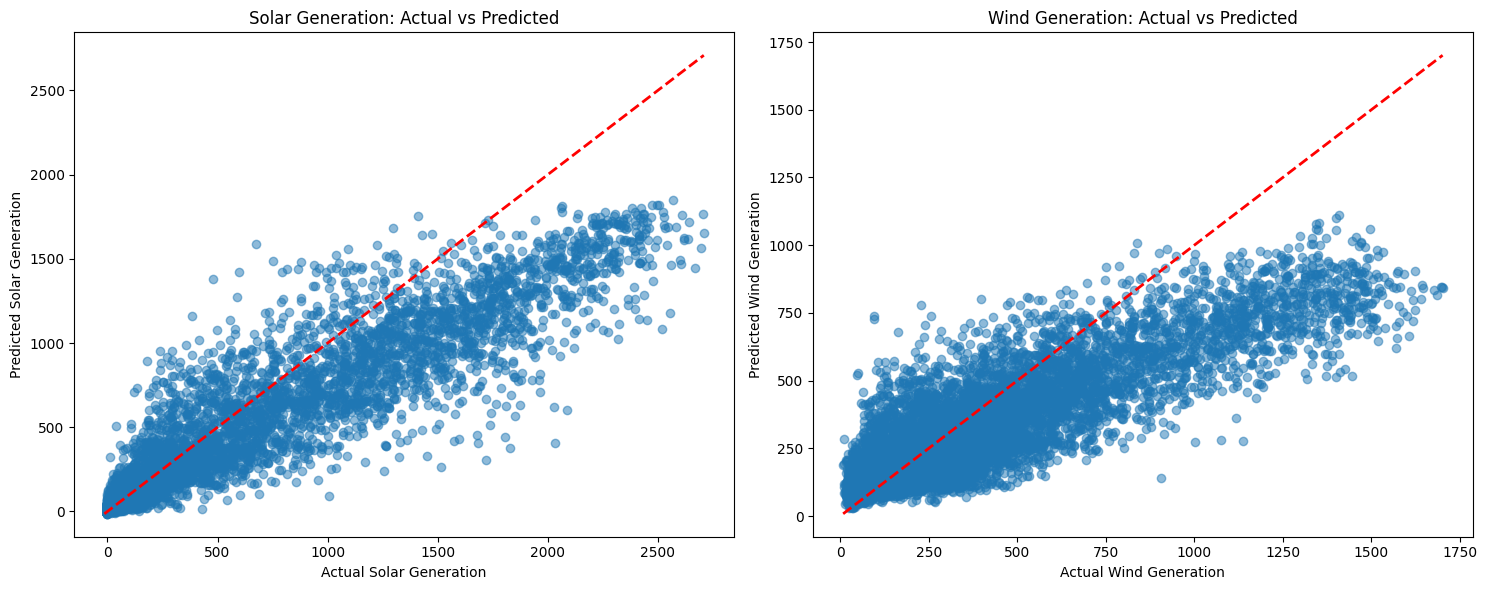

In [63]:
# ==== STEP 4: Predict and inverse transform ====
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Predict and convert dict to DataFrame
y_pred_raw = model.predict(X_test_seq)
y_pred_seq = pd.DataFrame(
    np.hstack([y_pred_raw['solar_output'], y_pred_raw['wind_output']]),
    columns=target_cols
)

# Inverse transform
y_test_inv = pd.DataFrame(target_scaler.inverse_transform(y_test_seq), columns=target_cols)
y_pred_inv = pd.DataFrame(target_scaler.inverse_transform(y_pred_seq), columns=target_cols)


metrics = {}

for col in target_cols:
    y_true = y_test_inv[col].values
    y_pred = y_pred_inv[col].values

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    metrics[col] = {
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'R² Score': round(r2, 4)
    }

metrics_df = pd.DataFrame(metrics).T
metrics_df.index.name = "Target"
print(metrics_df)


# ==== STEP 5: Plot actual vs predicted scatter ====

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for i, (col, title) in enumerate(zip(target_cols, ['Solar Generation', 'Wind Generation'])):
    ax = axes[i]
    ax.scatter(y_test_inv[col], y_pred_inv[col], alpha=0.5)
    min_val = min(y_test_inv[col].min(), y_pred_inv[col].min())
    max_val = max(y_test_inv[col].max(), y_pred_inv[col].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    ax.set_xlabel(f'Actual {title}')
    ax.set_ylabel(f'Predicted {title}')
    ax.set_title(f'{title}: Actual vs Predicted')
plt.tight_layout()
plt.show()

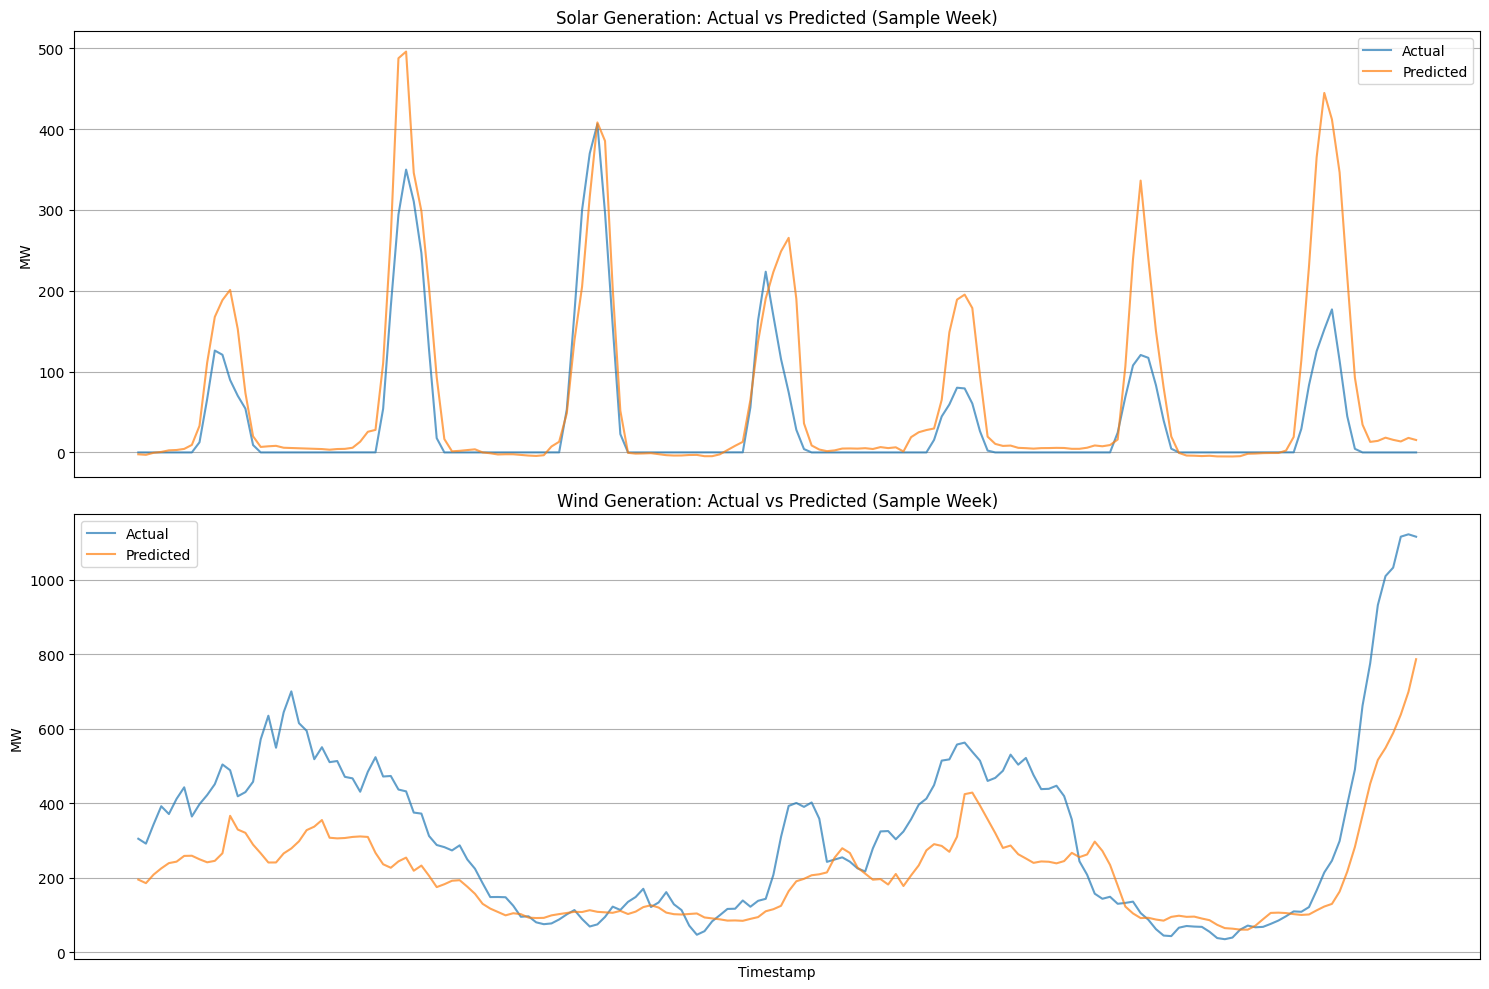

In [64]:
# ==== STEP 6: Plot sample week time series ====

sample_size = 168  # One week of hourly data

# Extract the correct timestamps that align with the test sequence
sample_index = pd.to_datetime(time_test[:sample_size])

# Match the same timestamps to predictions
y_test_sample = y_test_inv.iloc[:sample_size]
y_pred_sample = y_pred_inv.iloc[:sample_size]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Solar
ax1.plot(sample_index, y_test_sample[target_cols[0]], label='Actual', alpha=0.7)
ax1.plot(sample_index, y_pred_sample[target_cols[0]], label='Predicted', alpha=0.7)
ax1.set_title('Solar Generation: Actual vs Predicted (Sample Week)')
ax1.set_ylabel('MW')
ax1.grid(True)
ax1.legend()

# Wind
ax2.plot(sample_index, y_test_sample[target_cols[1]], label='Actual', alpha=0.7)
ax2.plot(sample_index, y_pred_sample[target_cols[1]], label='Predicted', alpha=0.7)
ax2.set_title('Wind Generation: Actual vs Predicted (Sample Week)')
ax2.set_ylabel('MW')
ax2.set_xlabel('Timestamp')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()


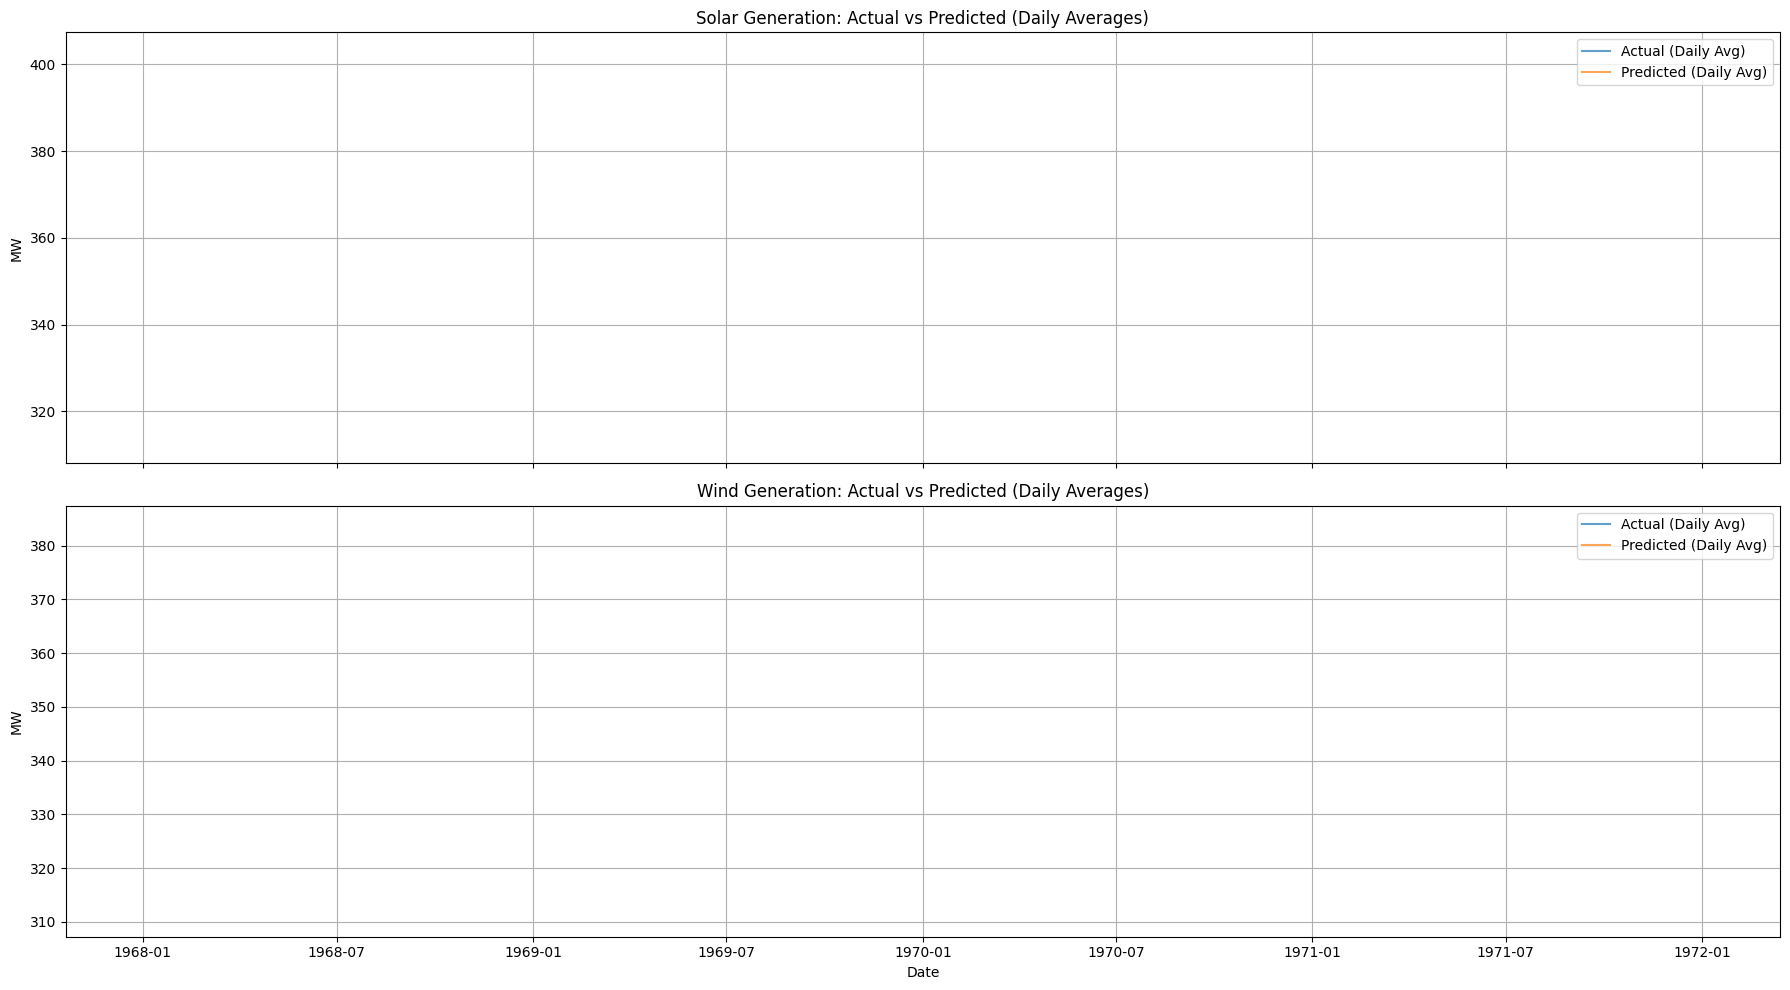

In [65]:
# ==== STEP 6B: Plot full year time series (Daily Averaged) ====

# Define sample size (hourly data for one year)
sample_size = 8760

# Convert the time index to datetime
sample_index = pd.to_datetime(time_test[:sample_size])

# Create DataFrames with datetime index
y_test_sample = y_test_inv.iloc[:sample_size].copy()
y_pred_sample = y_pred_inv.iloc[:sample_size].copy()
y_test_sample.index = sample_index
y_pred_sample.index = sample_index

# Resample to daily average
y_test_daily = y_test_sample.resample('D').mean()
y_pred_daily = y_pred_sample.resample('D').mean()

# Create plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# Solar Generation
ax1.plot(y_test_daily.index, y_test_daily[target_cols[0]], label='Actual (Daily Avg)', alpha=0.7)
ax1.plot(y_pred_daily.index, y_pred_daily[target_cols[0]], label='Predicted (Daily Avg)', alpha=0.7)
ax1.set_title('Solar Generation: Actual vs Predicted (Daily Averages)')
ax1.set_ylabel('MW')
ax1.grid(True)
ax1.legend()

# Wind Generation
ax2.plot(y_test_daily.index, y_test_daily[target_cols[1]], label='Actual (Daily Avg)', alpha=0.7)
ax2.plot(y_pred_daily.index, y_pred_daily[target_cols[1]], label='Predicted (Daily Avg)', alpha=0.7)
ax2.set_title('Wind Generation: Actual vs Predicted (Daily Averages)')
ax2.set_ylabel('MW')
ax2.set_xlabel('Date')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()


274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


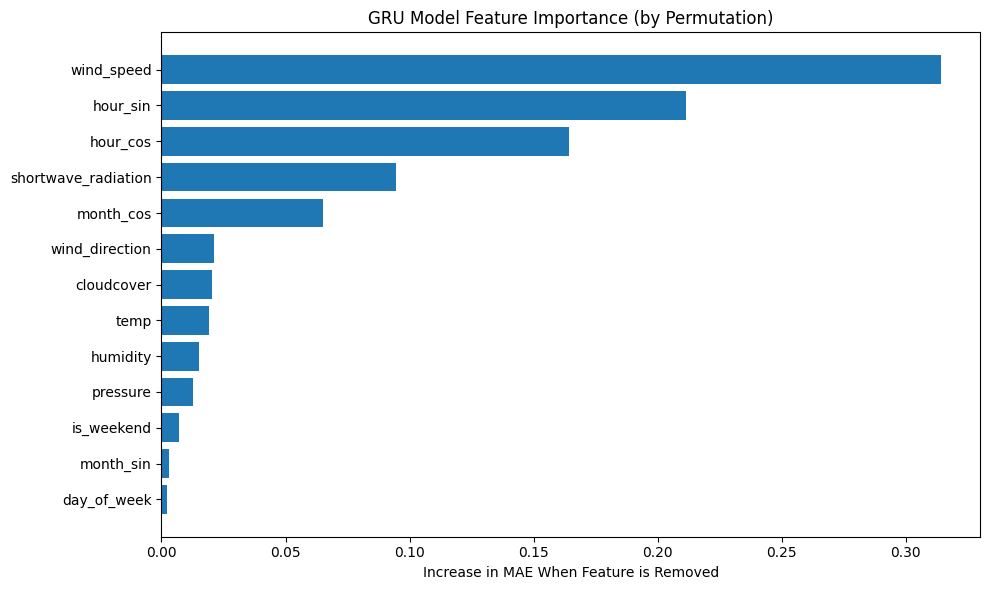

In [54]:
## FEATURE IMPORTANCE

# Baseline performance
y_pred_baseline = model.predict(X_test_seq)
baseline_mae = mean_absolute_error(y_test_seq, y_pred_baseline)

importances = []

for i in range(X_test_seq.shape[2]):  # loop over each feature
    X_test_permuted = X_test_seq.copy()
    np.random.shuffle(X_test_permuted[:, :, i])  # permute the feature across time steps

    y_pred_permuted = model.predict(X_test_permuted)
    permuted_mae = mean_absolute_error(y_test_seq, y_pred_permuted)
    
    importance = permuted_mae - baseline_mae
    importances.append(importance)

# Convert to DataFrame
feature_names = X.columns if isinstance(X, pd.DataFrame) else [f'feat_{i}' for i in range(X_test_seq.shape[2])]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance (MAE Δ)': importances
}).sort_values(by='Importance (MAE Δ)', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance (MAE Δ)'])
plt.gca().invert_yaxis()
plt.xlabel('Increase in MAE When Feature is Removed')
plt.title('GRU Model Feature Importance (by Permutation)')
plt.tight_layout()
plt.show()

## Time Series Cross-Validation (K-Fold Forward Chaining)

In [66]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import numpy as np

n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)
mae_scores, rmse_scores = [], []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_seq)):
    print(f"Fold {fold+1}/{n_splits}")
    
    X_train_fold, X_test_fold = X_seq[train_idx], X_seq[test_idx]
    y_train_fold, y_test_fold = y_seq[train_idx], y_seq[test_idx]

    # Define a fresh GRU model
    model = tf.keras.Sequential([
        tf.keras.layers.GRU(128, return_sequences=False, input_shape=(X_train_fold.shape[1], X_train_fold.shape[2])),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(2)  # Solar and wind
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    model.fit(X_train_fold, y_train_fold, epochs=20, batch_size=64, verbose=0)
    
    y_pred_fold = model.predict(X_test_fold)
    y_pred_fold_inv = target_scaler.inverse_transform(y_pred_fold)
    y_test_fold_inv = target_scaler.inverse_transform(y_test_fold)

    # Evaluate
    mae = np.mean(np.abs(y_test_fold_inv - y_pred_fold_inv))
    rmse = np.sqrt(mean_squared_error(y_test_fold_inv, y_pred_fold_inv))

    mae_scores.append(mae)
    rmse_scores.append(rmse)

print(f"\nAverage MAE across folds: {np.mean(mae_scores):.2f}")
print(f"Average RMSE across folds: {np.mean(rmse_scores):.2f}")


Fold 1/5


C:\Users\danee\PycharmProjects\Project-2-2\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Fold 2/5


C:\Users\danee\PycharmProjects\Project-2-2\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Fold 3/5


...

229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Fold 4/5


C:\Users\danee\PycharmProjects\Project-2-2\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Fold 5/5


C:\Users\danee\PycharmProjects\Project-2-2\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Average MAE across folds: 98.02
Average RMSE across folds: 160.42


results:
Average MAE across folds: 96.36
Average RMSE across folds: 160.10

# 🌞⚡ Progress Recap

## ✅ Goals Achieved So Far

### 🧠 Models Trained
- **Feedforward Neural Network (FFN)**:
  - Captured seasonality only to a limited extent.
  - Predictions were flat and didn't resemble expected solar patterns.
  - **Issue**: Temporal relationships were not well modeled.

- **Gated Recurrent Unit (GRU) Model**:
  - **Major breakthrough!** Captured daily solar patterns beautifully.
  - Solar predictions now follow the expected sinusoidal shape.
  - Wind predictions show improvement, but **still lack fine-grained variance**.

### 📊 Evaluation Metrics
| Target                        | Model | MAE     | RMSE    | R² Score |
|------------------------------|-------|---------|---------|----------|
| ES_solar_generation_actual   | GRU   | ✅ Lower | ✅ Lower | ✅ High   |
| ES_wind_onshore_generation_actual | GRU | Better but needs improvement | — | ❌ Low |

### 📈 Visual Results
- **Solar**: Excellent performance with GRU. Smooth and aligned with ground truth.
- **Wind**: Predictions are smoother but still oversimplified compared to actuals.

---

## 🔍 Key Takeaways

- GRU models are **essential for temporal forecasting** like energy generation.
- **Solar generation** is strongly seasonal and cyclical — well captured by current features (especially `hour_cos`, `month_cos`, etc.).
- **Wind generation**, however, appears **more stochastic and volatile**, which the model **cannot fully learn from time features alone**.
